In [1]:
import gc
import sys
from pathlib import Path

# Ensure project root is in sys.path
root_dir = Path.cwd().resolve()
if root_dir.name in ("terrain_diffusion", "working"):
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

# Set PyTorch expandable segments
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Clean stale models, tensors, and cached memory from VRAM if re-running
for _k in list(globals().keys()):
    _v = globals().get(_k)
    if _v is not None and (
        hasattr(_v, "to") or hasattr(_v, "parameters") or _k in ("elev_map", "pipe", "pipeline")
    ):
        try:
            del globals()[_k]
        except Exception:
            pass

if hasattr(sys, "last_traceback"):
    sys.last_traceback = None
    sys.last_value = None
    sys.last_type = None

gc.collect()

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Check NVIDIA hardware access and VRAM availability
assert torch.cuda.is_available(), "NVIDIA GPU hardware is not accessible via PyTorch CUDA runtime."

device_idx = torch.cuda.current_device()
device_name = torch.cuda.get_device_name(device_idx)
free_bytes, total_bytes = torch.cuda.mem_get_info(device_idx)
free_gb = free_bytes / (1024 ** 3)
total_gb = total_bytes / (1024 ** 3)

print(f"NVIDIA GPU: {device_name} (Device {device_idx})")
print(f"VRAM: {free_gb:.2f} GB free / {total_gb:.2f} GB total")

# Threshold check (recommended ~2.0 GB min free memory for generation)
MIN_VRAM_GB = 2.0
if free_gb < MIN_VRAM_GB:
    print(f"[WARN] Free VRAM ({free_gb:.2f} GB) is below the recommended {MIN_VRAM_GB:.1f} GB. Other GPU processes may cause OOM.")
else:
    print("[PASS] GPU hardware accessible with sufficient VRAM.")

import ast
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from terrain_diffusion.paths import get_project_path

with open(get_project_path("legends/topography.txt"), "r") as data:
    cdict = ast.literal_eval(data.read())
    topo = LinearSegmentedColormap('topo', cdict)

NVIDIA GPU: NVIDIA GeForce RTX 4070 SUPER (Device 0)
VRAM: 10.33 GB free / 11.59 GB total
[PASS] GPU hardware accessible with sufficient VRAM.


In [2]:
from PIL import Image
Image.MAX_IMAGE_PIXELS = None
from pathlib import Path

# folder containing the source data
source_folder = "working/92757802"

# fetch the source data from the folder and scale elevations to suit terrain_diffusion input
img = Image.open(Path.joinpath(Path(get_project_path(source_folder)), "heightfield.tif"))
arr = np.array(img)
arr *= 4096
arr -= 2048

world_coarse_map = Image.fromarray(arr)

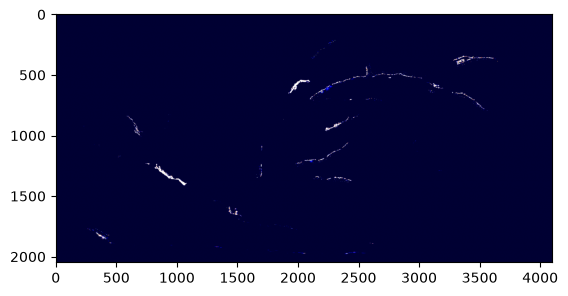

In [3]:
from matplotlib import pyplot as plt

plt.imshow(world_coarse_map.convert('L'), cmap=topo)


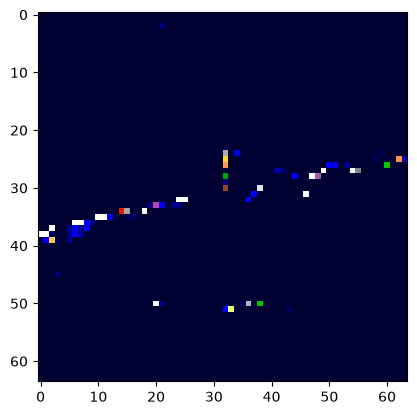

In [4]:
import coarse_map as cm

lat = 45.0
lon = 45.0
size = 64
extent = 3000

mapper = cm.CoarseMap (size=size, extent=extent)
mapper.add_channel (coarse_map = world_coarse_map, channel = "heightmap")
cond_map = mapper.get_cond_map (lat = 45.0, lon = 45.0)
preview = Image.fromarray (cond_map)
plt.imshow(preview.convert('L'), cmap=topo)



In [5]:
from oswald.generate_map import MapGenerator

generator = MapGenerator(
    device="cuda",
    seed=42,
    snr="0.1,0.2,1.0,0.2,1.0",
    batch_size=2,
    dtype= "fp32",
    torch_compile=False,
    caching_strategy="direct")
elev_map = generator.generate(cond_map)
generator.close()  # frees VRAM

print ("Done.")

/home/ferret/src/terrain-diffusion/envs/conda/py_3.11/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/ferret/src/terrain-diffusion/envs/conda/py_3.11/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Synthetic map stats cache hit.
MapGenerator initialized on cuda. World seed: 42
Synthetic map stats cache hit.
  Imported heightmap → channel 0, padded shape: (192, 192)
  Skipping temperature (not provided). Perlin noise will be used instead.
  Skipping temperature_std (not provided). Perlin noise will be used instead.
  Skipping precipitation (not provided). Perlin noise will be used instead.
  Skipping precipitation_cv (not provided). Perlin noise will be used instead.
Synthetic map stats cache hit.


Generating: 100%|██████████| 64/64 [06:46<00:00,  6.36s/it]


Done.


In [6]:
import importlib
import terrain_diffusion.inference.viewer as viewer_module
importlib.reload(viewer_module)

out_viewer = viewer_module.TiffViewer(elev_map, cmap=topo, display_size=800)
out_viewer.show()

out_viewer.set_relief_shading(True)
out_viewer.set_relief_intensity(2.0)
out_viewer.refresh()
